# 15-Parameter Shortwave Calibration (Thesis Reproduction)

Reproduces the **multi-parameter shortwave calibration** from Chapter 5 of the thesis
("Multi-Parameter calibration", Table 5.4 / `tab:sw_params_15`), using the
`SpeedyCalibration.jl` package API. The original run was performed with the
ad-hoc `train_multi_param_online_v5` function in
`differentiability/main/point_wise_loss/5param_osr_temp_train.ipynb`
(the `training_params_15` block); this notebook is the equivalent workflow
using the packaged `calibrate!` API.

**Goal**: jointly tune 15 parameters spanning cloud reflection, atmospheric
absorption, and surface albedo against the Trenberth (2009) shortwave energy
budget:

| Flux | Target | Description |
|------|--------|--------------|
| OSR | 101.9 W/m² | Outgoing shortwave radiation (TOA, reflected) |
| SRU | 23.1 W/m²  | Surface shortwave up (reflected) |
| SRD | 184.3 W/m² | Surface shortwave down |

**Method**: online statistical gradient estimation — average single-timestep
Enzyme gradients over a continuously-running simulation (no differentiation
through the full trajectory), exactly as in the thesis.

In [2]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))   # SpeedyCalibration.jl project
Pkg.instantiate()

using SpeedyCalibration
using CairoMakie
using GeoMakie
using Optimisers
using Dates
using Printf

println("SpeedyCalibration.jl ready.")

  Activating project at `~/master_thesis/Code_SpeedyWeather/SpeedyCalibration.jl`
Precompiling packages...
 216493.9 ms  ✓ SpeedyCalibration
  1 dependency successfully precompiled in 218 seconds. 214 already precompiled.
[ Info: Precompiling SpeedyCalibration [5d65bc14-e915-412c-9a7c-d2e552044b02]
[ Info: Precompiling CairoMakie [13f3f980-e62b-5c42-98c6-ff1f3baf88f0]
[ Info: Precompiling ModelParametersUnitfulExt [30a72cc9-359b-520d-a5bb-2064a7c97f0f]
[ Info: Precompiling ModelParametersMakieExt [fe55f67a-76af-556c-8c6e-f9ee716b975d]
[ Info: Precompiling DomainSetsMakieExt [da481366-01c8-5b4d-b359-47a10c8532e7]
[ Info: Precompiling RingGridsMakieExt [e5dccbbd-f882-5bb0-bb40-f730cea6c903]


SpeedyCalibration.jl ready.


## 1. Define the 15 trainable parameters

Groups and bounds are copied verbatim from Table 5.4 of the thesis
(`training_params_15` in `5param_osr_temp_train.ipynb`):

| Group | Name | Bounds | Initial |
|---|---|---|---|
| Cloud | `cloud_albedo` | [0.25, 0.95] | 0.60 |
| Cloud | `stratocumulus_cover_max` | [0.25, 0.95] | 0.60 |
| Cloud | `stratocumulus_albedo` | [0.10, 0.90] | 0.50 |
| Cloud cover | `precipitation_weight` | [0.0, 0.8] | 0.20 |
| Atm. absorption | `absorptivity_water_vapor` | [60, 140] | 75 |
| Atm. absorption | `absorptivity_dry_air` | [0.005, 0.060] | 0.031 |
| Atm. absorption | `absorptivity_aerosol` | [0.005, 0.060] | 0.031 |
| Atm. absorption | `ozone_absorption` | [0.002, 0.020] | 0.010 |
| Land albedo | `albedo_land` | [0.10, 0.70] | 0.40 |
| Land albedo | `albedo_high_vegetation` | [0.04, 0.26] | 0.15 |
| Land albedo | `albedo_low_vegetation` | [0.05, 0.35] | 0.20 |
| Land albedo | `albedo_snow` | [0.15, 0.75] | 0.40 |
| Land albedo | `snow_depth_scale` | [0.005, 0.20] | 0.050 |
| Ocean/ice albedo | `albedo_ocean` | [0.02, 0.10] | 0.06 |
| Ocean/ice albedo | `albedo_ice` | [0.30, 0.90] | 0.60 |

In [3]:
param_specs = [
    # ── Cloud reflection (3) ──────────────────────────────────────────────────
    ParamSpec(:cloud_albedo,
        [:shortwave_radiation, :clouds, :cloud_albedo];
        bounds=(0.25f0, 0.95f0), initial=0.60f0),

    ParamSpec(:stratocumulus_cover_max,
        [:shortwave_radiation, :clouds, :stratocumulus_cover_max];
        bounds=(0.25f0, 0.95f0), initial=0.60f0),

    ParamSpec(:stratocumulus_albedo,
        [:shortwave_radiation, :clouds, :stratocumulus_albedo];
        bounds=(0.10f0, 0.90f0), initial=0.50f0),

    # ── Cloud cover (1) ───────────────────────────────────────────────────────
    ParamSpec(:precipitation_weight,
        [:shortwave_radiation, :clouds, :precipitation_weight];
        bounds=(0.0f0, 0.8f0), initial=0.20f0),

    # ── Atmospheric absorption (4) ───────────────────────────────────────────
    # absorptivity_water_vapor has a ~200× weaker physical gradient than the
    # cloud parameters (it is multiplied by specific humidity q ≈ 0.005 in the
    # radiation scheme). Lower bound raised to 60 (from 10): the model becomes
    # numerically unstable below ~57.
    ParamSpec(:absorptivity_water_vapor,
        [:shortwave_radiation, :transmissivity, :absorptivity_water_vapor];
        bounds=(60f0, 140f0), initial=75f0),

    ParamSpec(:absorptivity_dry_air,
        [:shortwave_radiation, :transmissivity, :absorptivity_dry_air];
        bounds=(0.005f0, 0.060f0), initial=0.03135f0),

    ParamSpec(:absorptivity_aerosol,
        [:shortwave_radiation, :transmissivity, :absorptivity_aerosol];
        bounds=(0.005f0, 0.060f0), initial=0.03135f0),

    ParamSpec(:ozone_absorption,
        [:shortwave_radiation, :radiative_transfer, :ozone_absorption];
        bounds=(0.002f0, 0.020f0), initial=0.01f0),

    # ── Land surface albedo (5) ──────────────────────────────────────────────
    ParamSpec(:albedo_land,
        [:albedo, :land, :albedo_land];
        bounds=(0.10f0, 0.70f0), initial=0.40f0),

    ParamSpec(:albedo_high_vegetation,
        [:albedo, :land, :albedo_high_vegetation];
        bounds=(0.04f0, 0.26f0), initial=0.15f0),

    ParamSpec(:albedo_low_vegetation,
        [:albedo, :land, :albedo_low_vegetation];
        bounds=(0.05f0, 0.35f0), initial=0.20f0),

    ParamSpec(:albedo_snow,
        [:albedo, :land, :albedo_snow];
        bounds=(0.15f0, 0.75f0), initial=0.40f0),

    ParamSpec(:snow_depth_scale,
        [:albedo, :land, :snow_depth_scale];
        bounds=(0.005f0, 0.20f0), initial=0.05f0),

    # ── Ocean/ice surface albedo (2) ─────────────────────────────────────────
    ParamSpec(:albedo_ocean,
        [:albedo, :ocean, :albedo_ocean];
        bounds=(0.02f0, 0.10f0), initial=0.06f0),

    ParamSpec(:albedo_ice,
        [:albedo, :ocean, :albedo_ice];
        bounds=(0.30f0, 0.90f0), initial=0.60f0),
]

println("$(length(param_specs)) parameters defined:")
for spec in param_specs
    @printf("  %-28s  init=%-10.5f  bounds=[%.4f, %.4f]\n",
            spec.name, spec.initial, spec.bounds...)
end

15 parameters defined:
  cloud_albedo                  init=0.60000     bounds=[0.2500, 0.9500]
  stratocumulus_cover_max       init=0.60000     bounds=[0.2500, 0.9500]
  stratocumulus_albedo          init=0.50000     bounds=[0.1000, 0.9000]
  precipitation_weight          init=0.20000     bounds=[0.0000, 0.8000]
  absorptivity_water_vapor      init=75.00000    bounds=[60.0000, 140.0000]
  absorptivity_dry_air          init=0.03135     bounds=[0.0050, 0.0600]
  absorptivity_aerosol          init=0.03135     bounds=[0.0050, 0.0600]
  ozone_absorption              init=0.01000     bounds=[0.0020, 0.0200]
  albedo_land                   init=0.40000     bounds=[0.1000, 0.7000]
  albedo_high_vegetation        init=0.15000     bounds=[0.0400, 0.2600]
  albedo_low_vegetation         init=0.20000     bounds=[0.0500, 0.3500]
  albedo_snow                   init=0.40000     bounds=[0.1500, 0.7500]
  snow_depth_scale              init=0.05000     bounds=[0.0050, 0.2000]
  albedo_ocean           

## 2. Configure the loss function

Three-flux MSE loss (OSR + SRU + SRD) with **equal weights** ($w_{osr}=w_{sru}=w_{srd}=1$),
matching the thesis exactly (Section "Multi-Parameter calibration"):

$$\mathcal{L}^{(b)} = w_{osr}(\bar{\mu}_{OSR}^{(b)} - 101.9)^2 + w_{sru}(\bar{\mu}_{SRU}^{(b)} - 23.1)^2 + w_{srd}(\bar{\mu}_{SRD}^{(b)} - 184.3)^2$$

In [4]:
# Targets from Wild et al. (2015) / Trenberth (2009) — same as the thesis run
sw_loss = LossConfig([:osr, :sru, :srd];
    targets = Dict(:osr => 101.9f0, :sru => 23.1f0, :srd => 184.3f0),
    weights = Dict(:osr => 1f0,     :sru => 1f0,     :srd => 1f0))

println("Loss: OSR=$(sw_loss.targets[:osr]) SRU=$(sw_loss.targets[:sru]) SRD=$(sw_loss.targets[:srd]) W/m²  (equal weights)")

Loss: OSR=101.9 SRU=23.1 SRD=184.3 W/m²  (equal weights)


## 3. Training configuration

Hyperparameters follow the thesis description as closely as the packaged API allows:

- `daily_cycle=true` — diurnal cycle **enabled** (unlike the 5-parameter baseline notebook), seasonal cycle disabled
- `start_date = 2000-03-21` — vernal equinox, so radiative forcing starts roughly symmetric between hemispheres
- `spinup_days=20` — 20-day spin-up before touching gradients
- `batch_days=30.0` — parameters updated every 30 simulated days
- `samples_per_batch=15` — 15 single-step gradient samples averaged per batch
- `max_batches=300` — thesis run converged at batch 81; this is a generous ceiling
- Adam learning rate `η=0.1`, gradients clipped before each step
- LR halved after 10 batches without improvement in the 20-batch smoothed loss, up to 5 times, floor `1e-5`
- Training stops once the 20-batch smoothed loss falls below `1.0`

In [5]:
config = TrainingConfig(
    spinup_days       = 20,
    batch_days        = 30.0,
    samples_per_batch = 15,
    max_batches       = 300,
    loss_window_size  = 20,
    loss_threshold    = 1f0,      # converge when 20-batch smoothed loss < 1 W²/m⁴
    patience          = 10,
    grad_clip         = 5f0,
    enable_lr_decay   = true,
    lr_decay_factor   = 0.5f0,
    lr_plateau_patience = 10,
    min_lr            = 1f-5,
    max_lr_decays     = 5,
    trunc             = 31,
    nlayers           = 8,
    start_date        = DateTime(2000, 3, 21),
    daily_cycle       = true,
    verbose           = true,
)
println(config)

TrainingConfig(20, 30.0, 15, 300, 20, 1.0f0, 10, 5.0f0, true, 0.5f0, 10, 1.0f-5, 5, 31, 8, DateTime("2000-03-21T00:00:00"), true, true, true)


## 4. Run calibration

`calibrate!` handles everything:
1. Builds the model and sets initial parameter values
2. Runs the spinup
3. Warms up Enzyme's AD rules on the spun-up model
4. Runs the batch loop: sample gradients → average → Adam step → reconstruct model
5. Saves all artifacts to `save_dir/`

**Runtime**: with the diurnal cycle enabled and 15 parameters this is
substantially slower than the 5-parameter baseline — expect several hours at T31,
dominated by Enzyme precompilation on the first call.

In [6]:
save_dir = joinpath(@__DIR__, "output", "thesis_15param_shortwave")

result = calibrate!(
    param_specs,
    Optimisers.Adam(1f-1),
    sw_loss,
    config;
    save_dir = save_dir,
)

SpeedyCalibration.jl — calibrate!
   1. cloud_albedo                     = 0.6000  [0.250, 0.950]  raw₀=0.000
   2. stratocumulus_cover_max          = 0.6000  [0.250, 0.950]  raw₀=0.000
   3. stratocumulus_albedo             = 0.5000  [0.100, 0.900]  raw₀=0.000
   4. precipitation_weight             = 0.2000  [0.000, 0.800]  raw₀=-1.099
   5. absorptivity_water_vapor         = 75.0000  [60.000, 140.000]  raw₀=-1.466
   6. absorptivity_dry_air             = 0.0314  [0.005, 0.060]  raw₀=-0.084
   7. absorptivity_aerosol             = 0.0314  [0.005, 0.060]  raw₀=-0.084
   8. ozone_absorption                 = 0.0100  [0.002, 0.020]  raw₀=-0.223
   9. albedo_land                      = 0.4000  [0.100, 0.700]  raw₀=0.000
  10. albedo_high_vegetation           = 0.1500  [0.040, 0.260]  raw₀=0.000
  11. albedo_low_vegetation            = 0.2000  [0.050, 0.350]  raw₀=0.000
  12. albedo_snow                      = 0.4000  [0.150, 0.750]  raw₀=-0.336
  13. snow_depth_scale                 = 0.0

   0%  ETA: 4:01:00 (2000-04-09, 597.20 years/day,  89 m/s, [ -80,   36] ˚C)

Spinup complete in 21.6 s.

Warming up Enzyme (compiling AD rules on actual model)...
Enzyme warmup complete in 216.1 s.


   0%  ETA: 42.89 days (2000-04-10,  2.33 years/day,  90 m/s, [ -80,   34] ˚C)

Starting training...
----------------------------------------------------------------------


...

   8%  ETA: 14:15:03 (2008-01-28, 155.17 years/day, 110 m/s, [-102,   25] ˚C)

Batch  95 | LR 2.5e-02 | osr=103.5 sru= 23.5 srd=184.6 | L̄     1.15 | Δp 1.9e-03


   8%  ETA: 13:54:41 (2008-04-27, 158.53 years/day,  95 m/s, [-114,   25] ˚C)

CONVERGED: smoothed_loss 0.9715 < 1.0000

TRAINING SUMMARY
  cloud_albedo                     0.6000 → 0.7602
  stratocumulus_cover_max          0.6000 → 0.5681
  stratocumulus_albedo             0.5000 → 0.4538
  precipitation_weight             0.2000 → 0.2650
  absorptivity_water_vapor         75.0000 → 73.4166
  absorptivity_dry_air             0.0314 → 0.0369
  absorptivity_aerosol             0.0314 → 0.0378
  ozone_absorption                 0.0100 → 0.0110
  albedo_land                      0.4000 → 0.4968
  albedo_high_vegetation           0.1500 → 0.1811
  albedo_low_vegetation            0.2000 → 0.2442
  albedo_snow                      0.4000 → 0.4255
  snow_depth_scale                 0.0500 → 0.0348
  albedo_ocean                     0.0600 → 0.0722
  albedo_ice                       0.6000 → 0.6211
----------------------------------------------------------------------
  Final osr : 102.25 W/m²  (target: 101.9)
  Final sru :  23.25 W/m²  (target: 23.1)
  Final srd : 184.

TrainingResult(98 batches, stop=smoothed loss below threshold (1.0), best_loss=0.9715)

## 5. Training summary

In [7]:
println(result)
println("\nFinal parameter values:")
for spec in param_specs
    v = result.final_params[spec.name]
    Δ = v - spec.initial
    @printf("  %-28s  init=%.4f  final=%.4f  Δ=%+.4f\n",
            spec.name, spec.initial, v, Δ)
end

println("\nFinal flux means (last batch):")
for k in [:osr, :sru, :srd]
    v = isempty(result.history[k]) ? NaN32 : result.history[k][end]
    t = sw_loss.targets[k]
    @printf("  %s: %.2f W/m²  (target %.1f,  Δ=%+.2f)\n", k, v, t, v - t)
end

TrainingResult(98 batches, stop=smoothed loss below threshold (1.0), best_loss=0.9715)

Final parameter values:
  cloud_albedo                  init=0.6000  final=0.7602  Δ=+0.1602
  stratocumulus_cover_max       init=0.6000  final=0.5681  Δ=-0.0319
  stratocumulus_albedo          init=0.5000  final=0.4538  Δ=-0.0462
  precipitation_weight          init=0.2000  final=0.2650  Δ=+0.0650
  absorptivity_water_vapor      init=75.0000  final=73.4166  Δ=-1.5834
  absorptivity_dry_air          init=0.0314  final=0.0369  Δ=+0.0056
  absorptivity_aerosol          init=0.0314  final=0.0378  Δ=+0.0065
  ozone_absorption              init=0.0100  final=0.0110  Δ=+0.0010
  albedo_land                   init=0.4000  final=0.4968  Δ=+0.0968
  albedo_high_vegetation        init=0.1500  final=0.1811  Δ=+0.0311
  albedo_low_vegetation         init=0.2000  final=0.2442  Δ=+0.0442
  albedo_snow                   init=0.4000  final=0.4255  Δ=+0.0255
  snow_depth_scale              init=0.0500  final=0.0348 

## 6. Plot training history

Reproduces Figure 5.x ("Training convergence of the 15-parameter shortwave
calibration") from the thesis: smoothed loss, OSR/SRU/SRD trajectories,
per-parameter trajectories, and gradient magnitudes.

In [10]:
using GeoMakie

[ Info: Precompiling GeoMakie [db073c08-6b98-4ee5-b6a4-5efafb3259c6]
[ Info: Precompiling RingGridsGeoMakieExt [2d315563-22ec-53cd-bb86-4034d5a6f7a6]
[ Info: Precompiling SpeedyWeatherGeoMakieExt [e8a06b79-132c-5f7f-a25c-66406c5f936d]
[ Info: Precompiling SpeedyCalibrationMakieExt [657b58ae-5d3d-567e-a598-44252c96ac46]


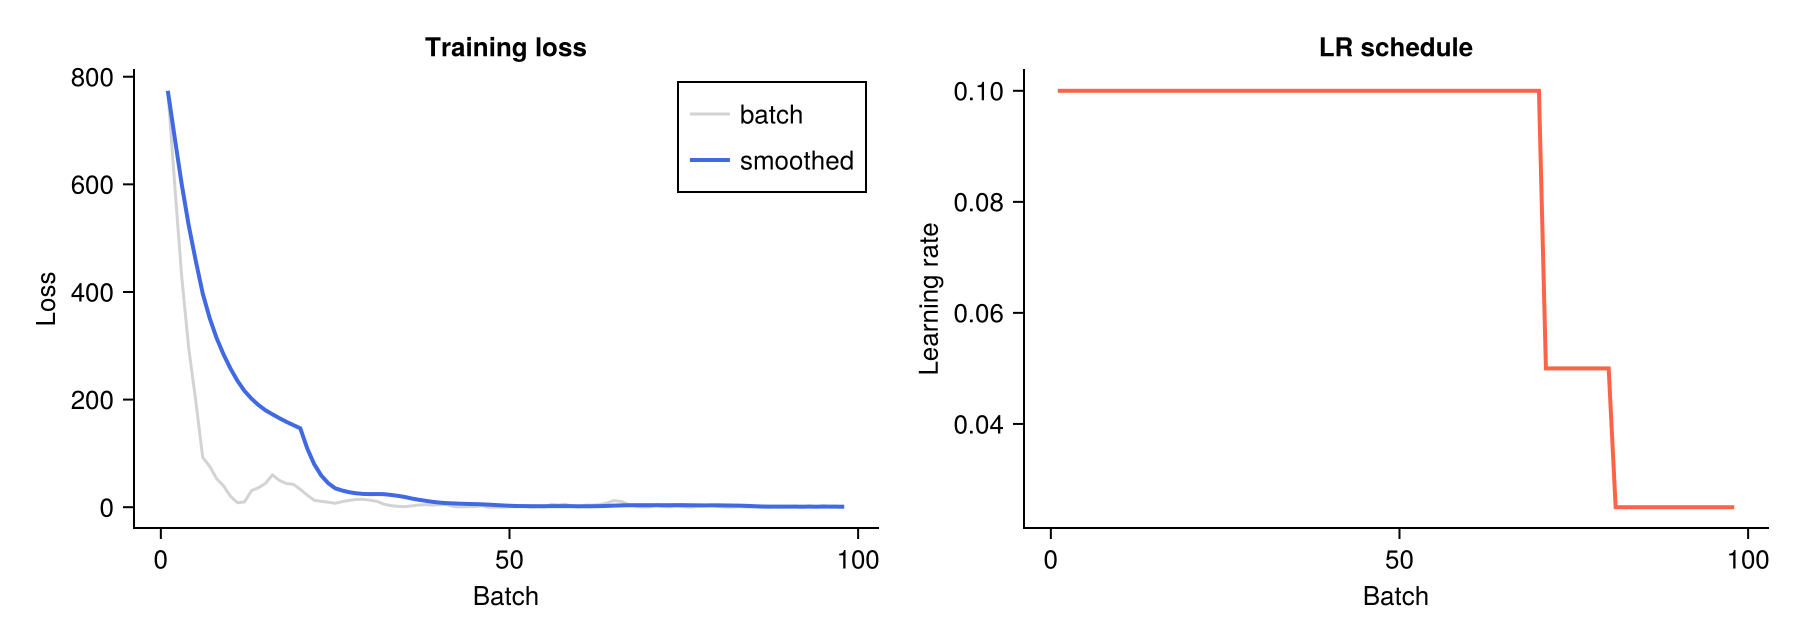

In [11]:
figs = plot_training(result; save_dir = save_dir)
figs.fig_loss

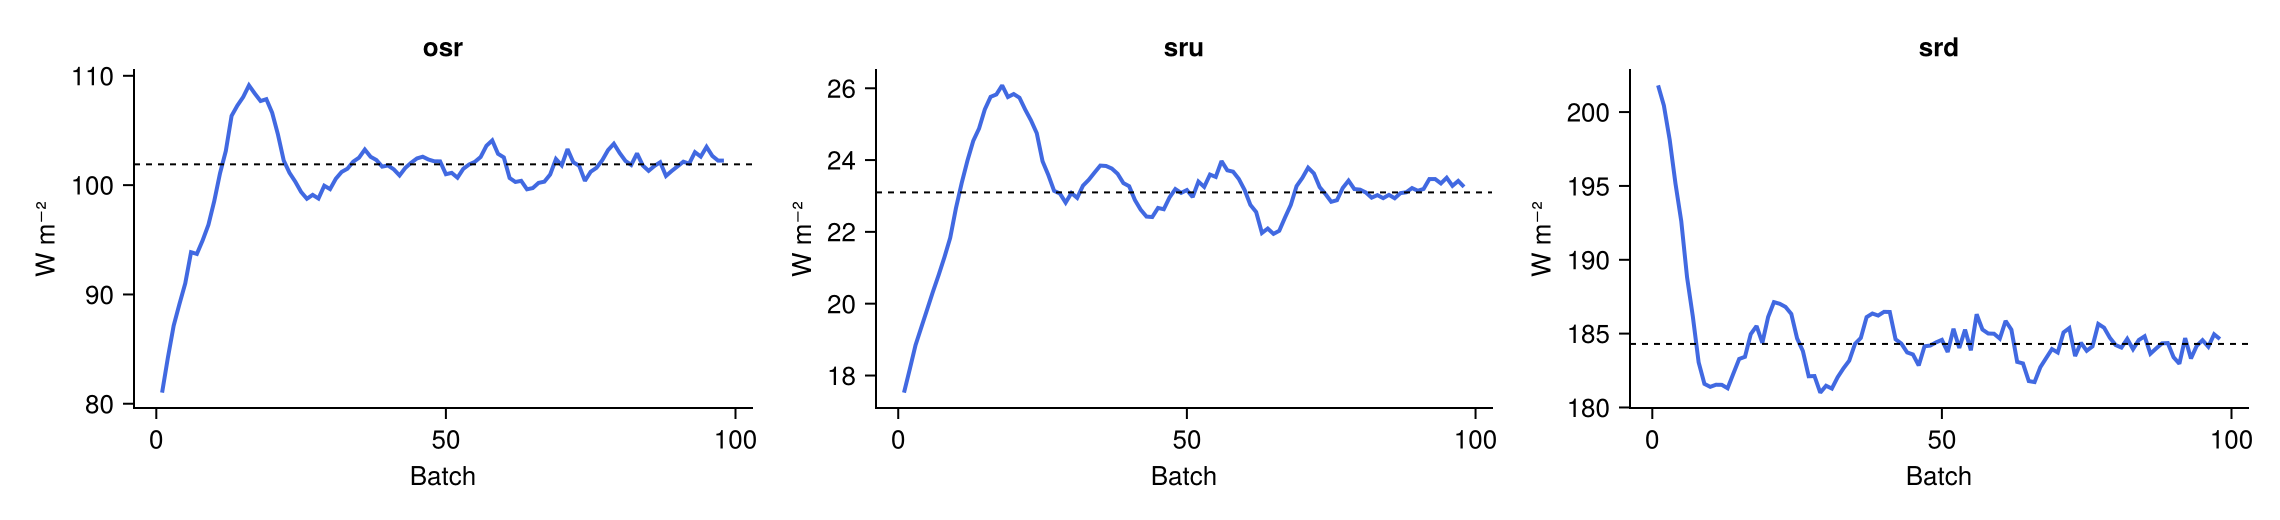

In [12]:
figs.fig_flux

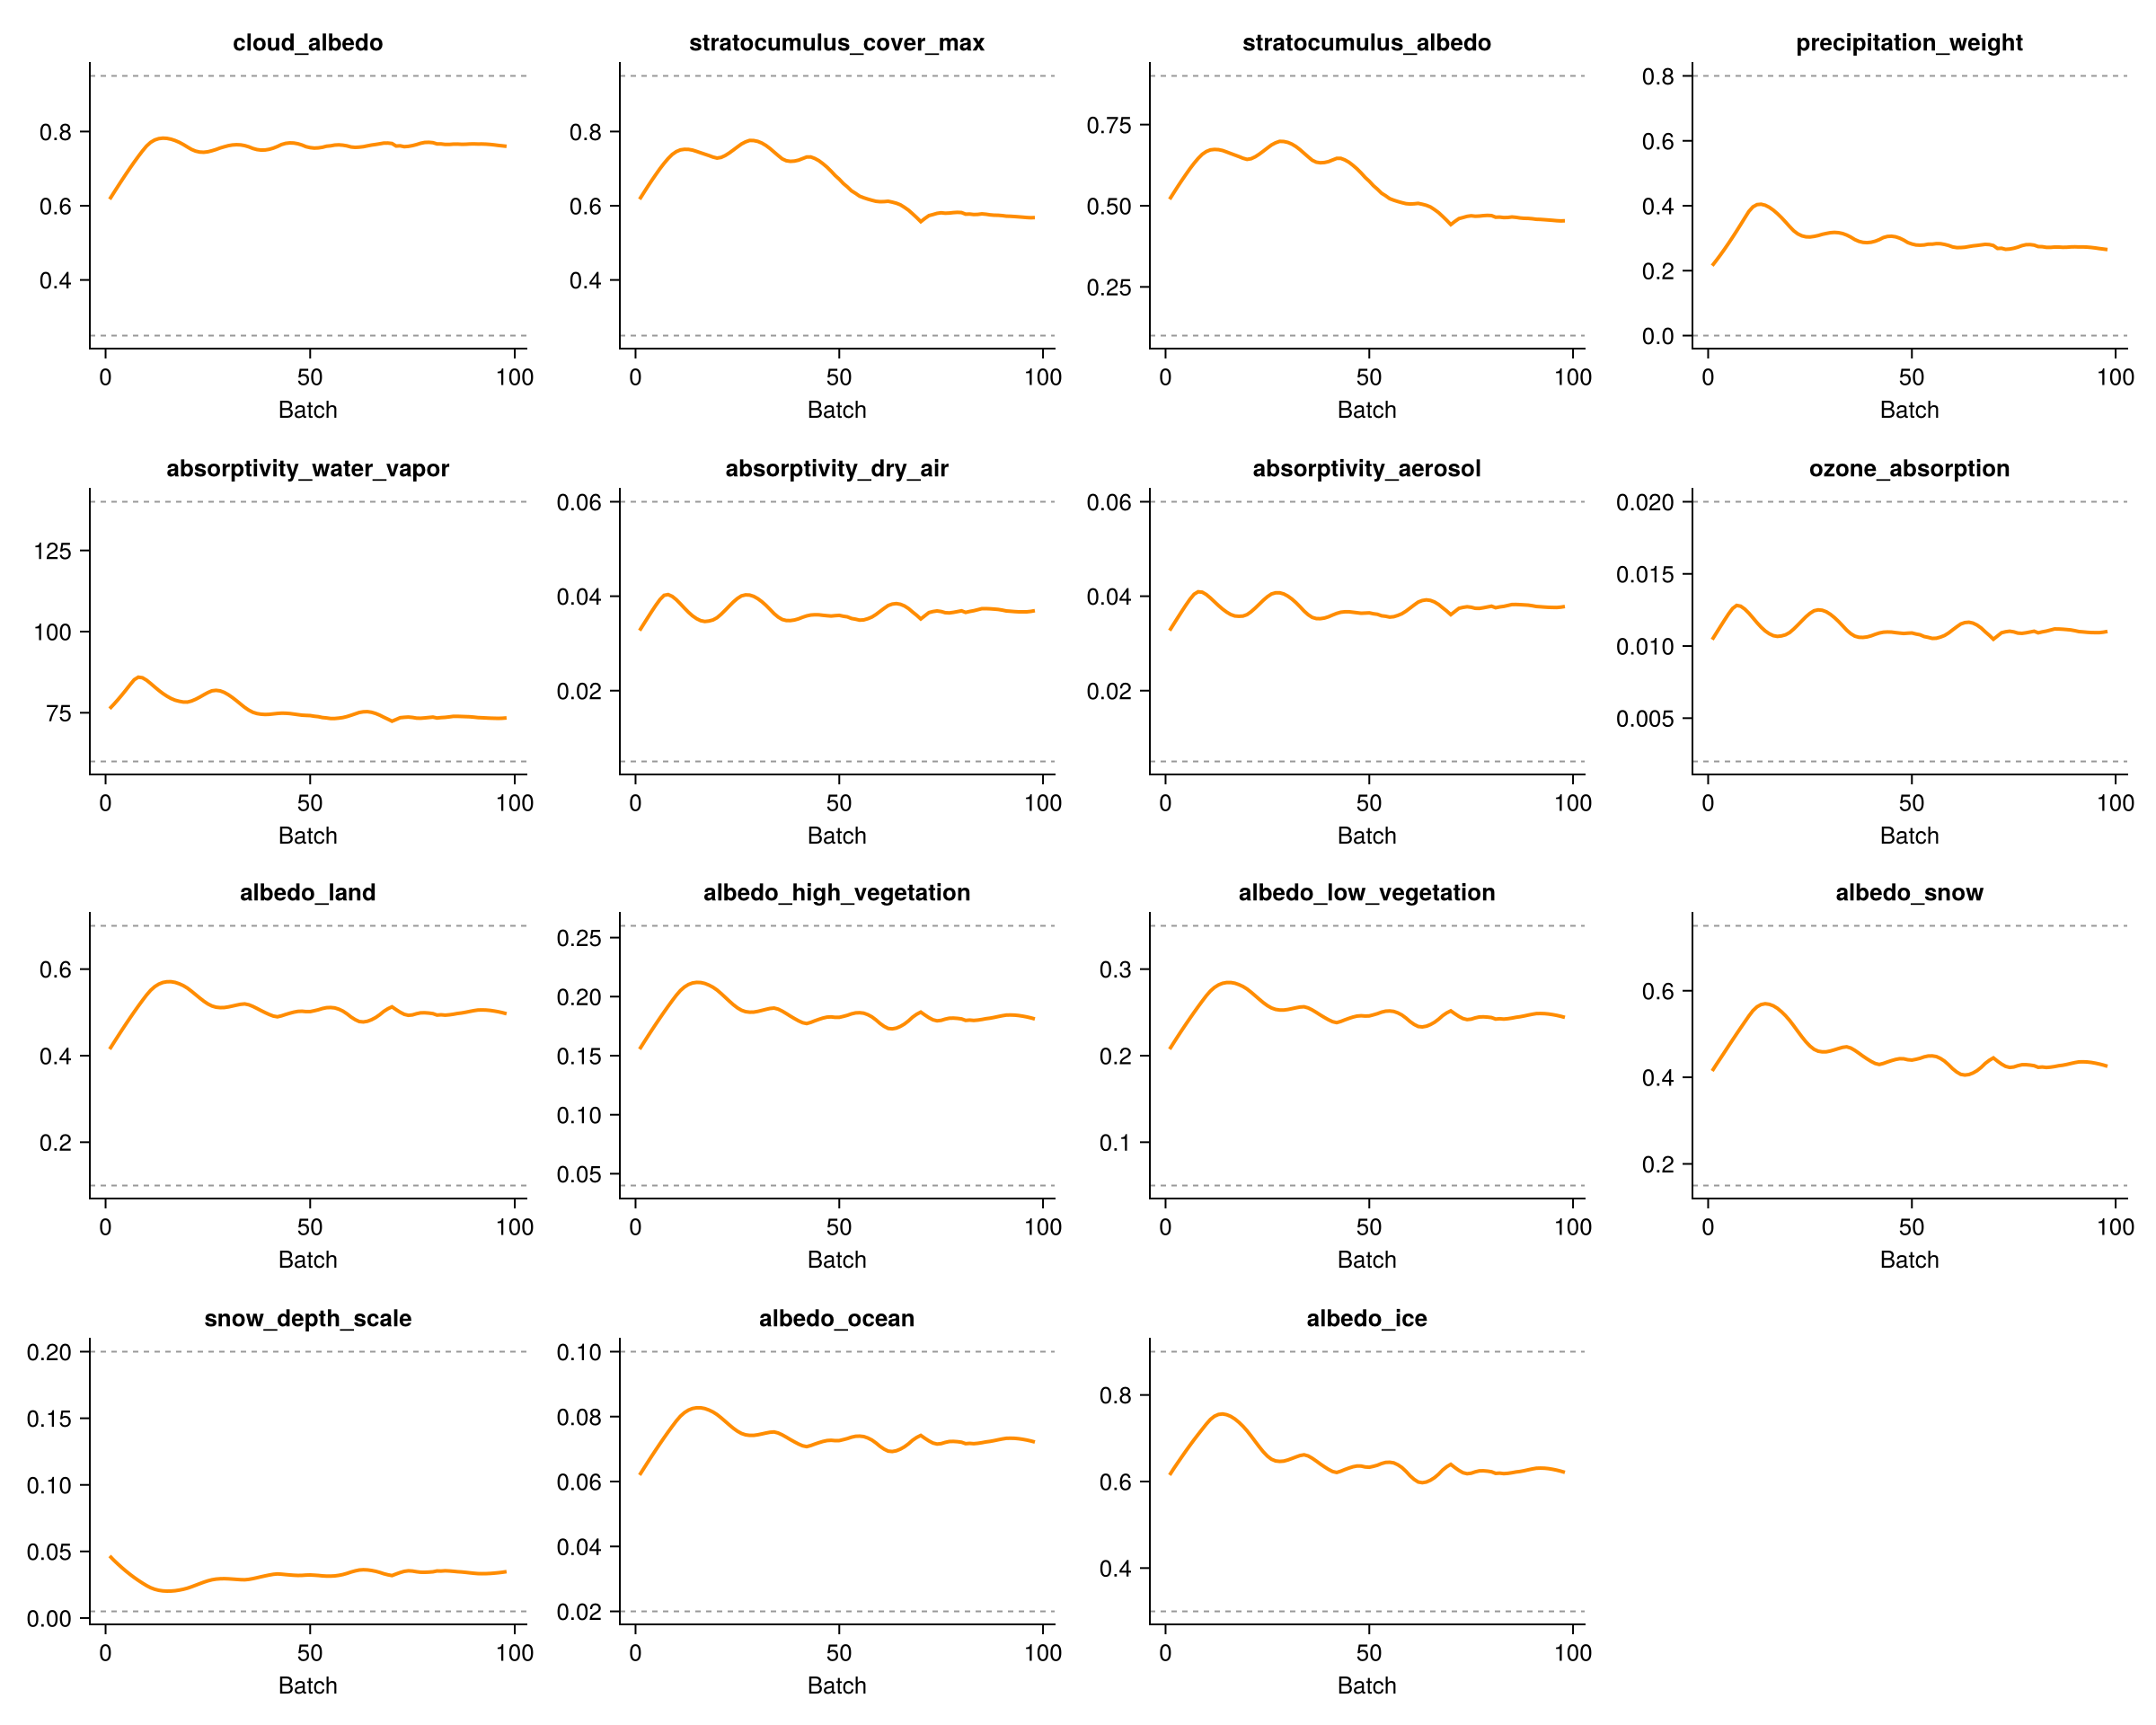

In [13]:
figs.fig_params

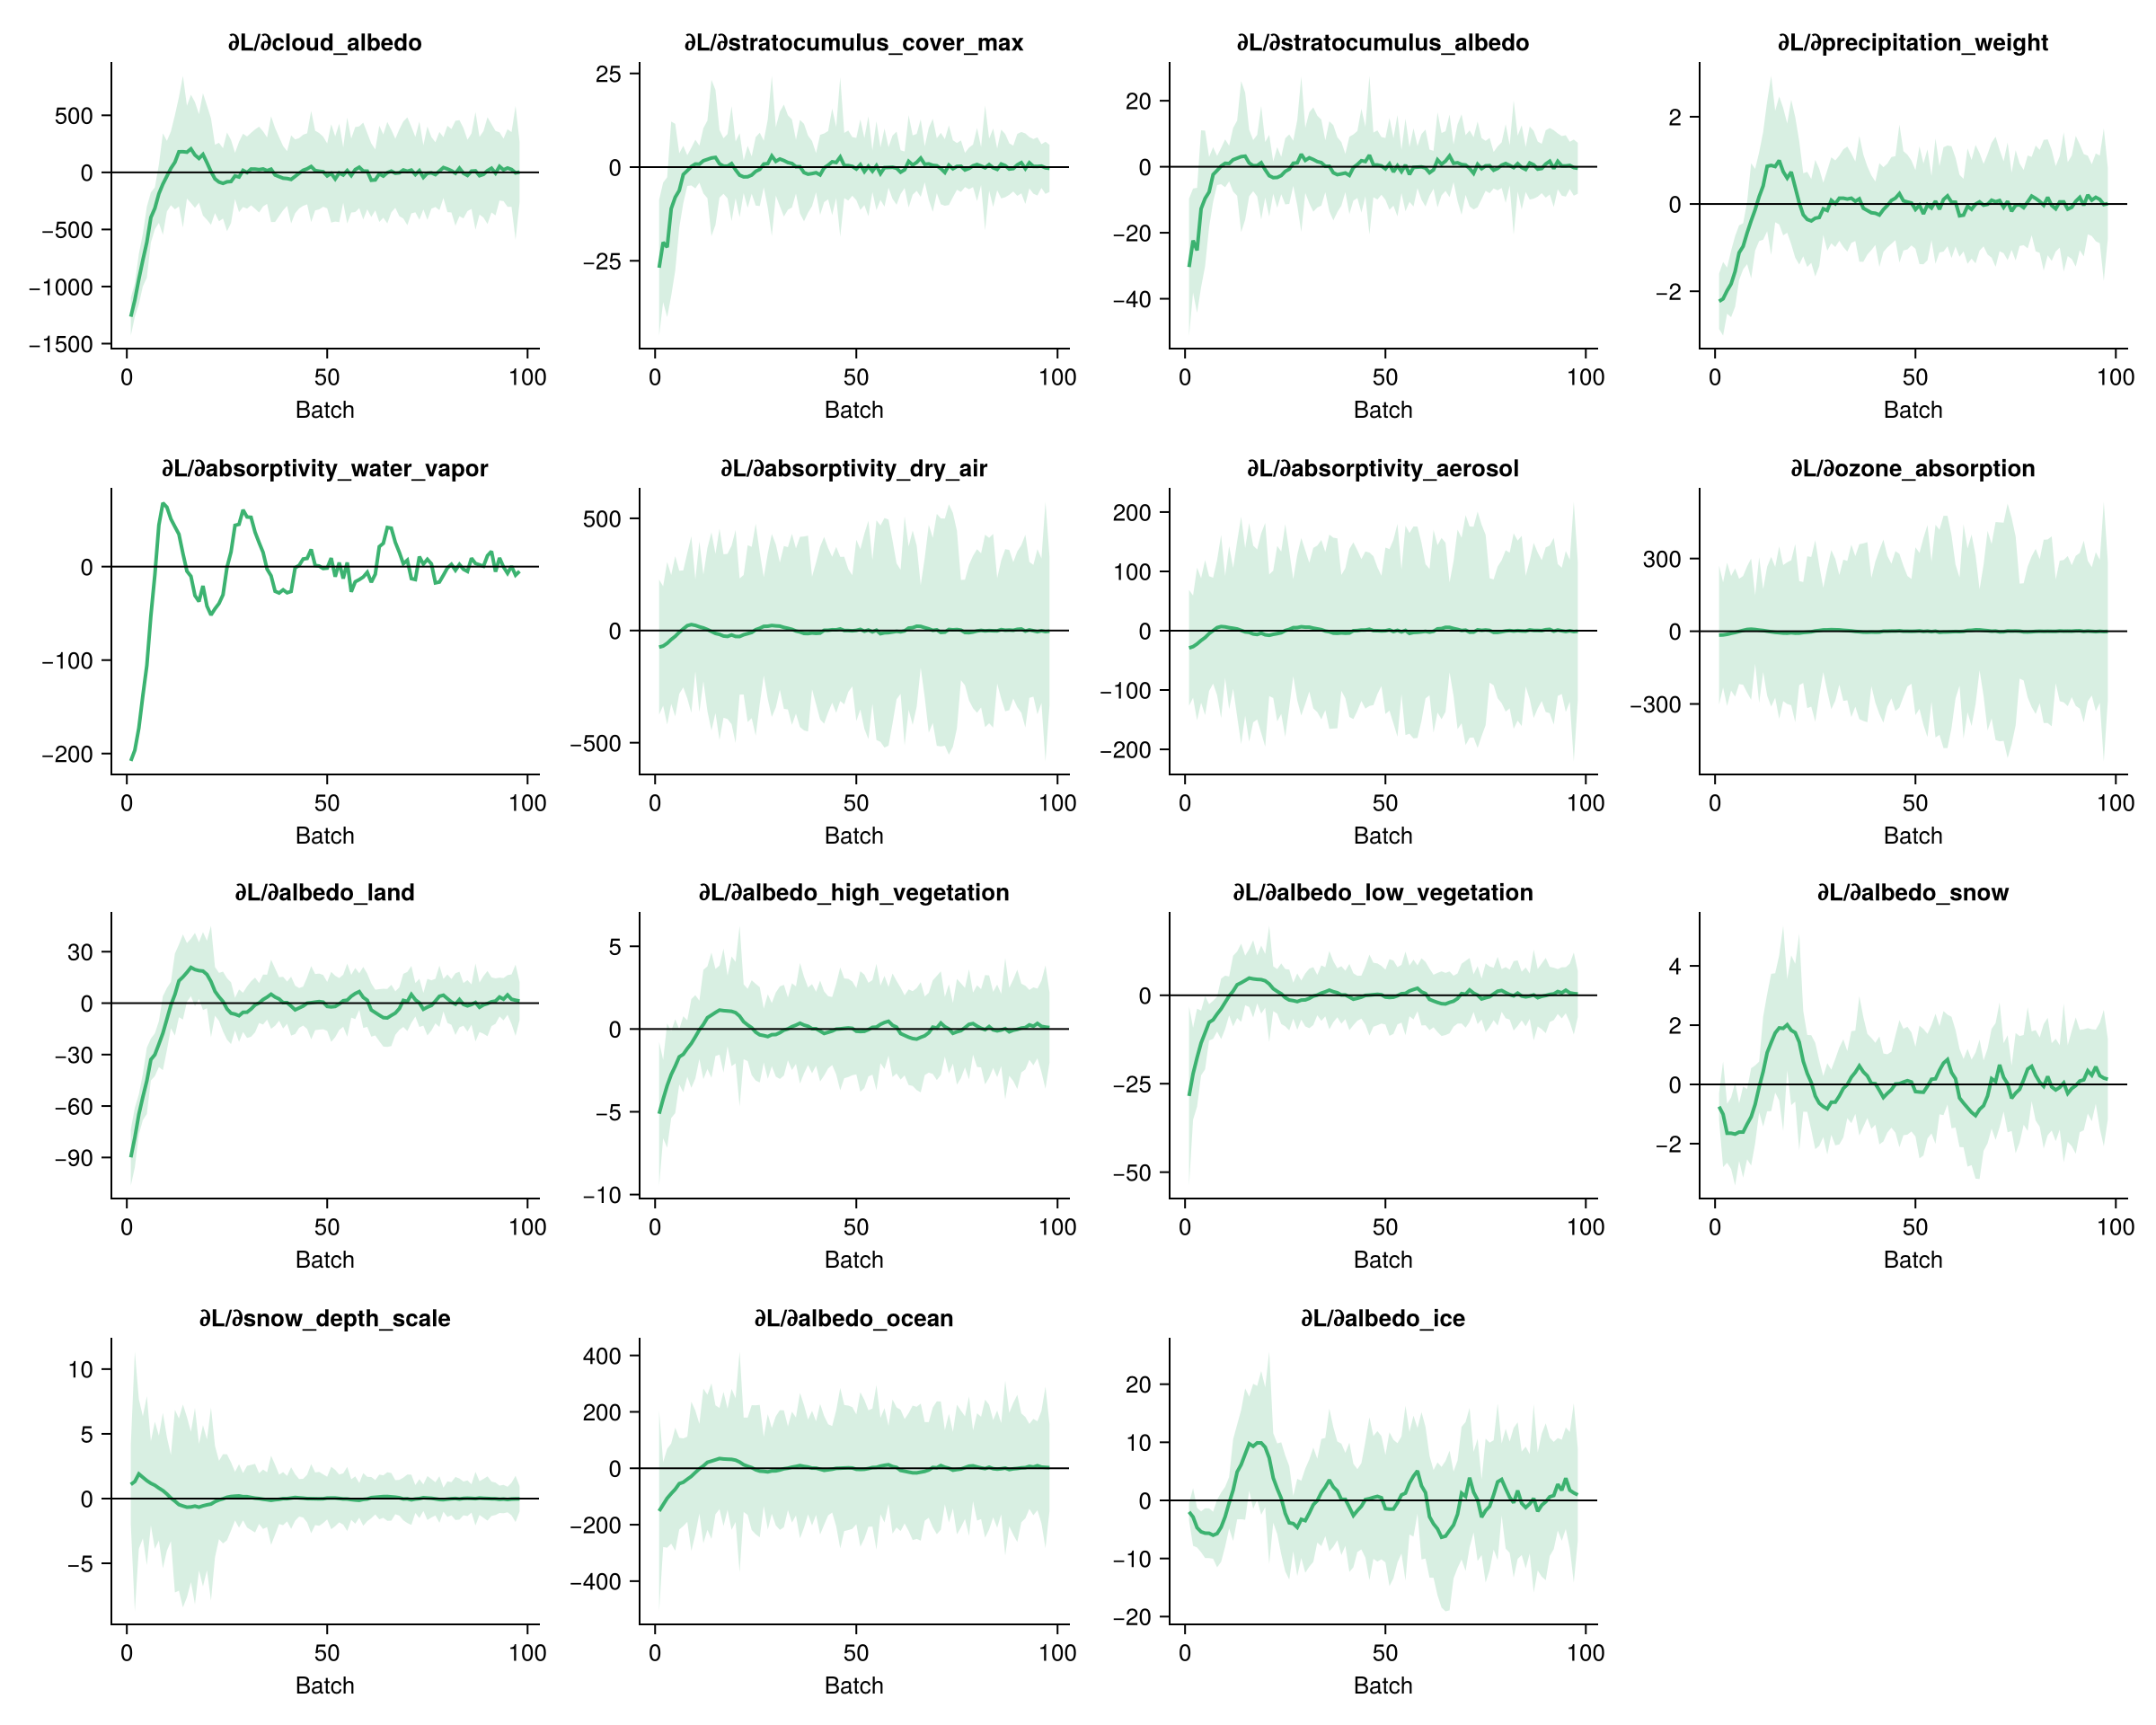

In [14]:
figs.fig_grads

## 7. Climate validation

Compare a 7-year run with **default** vs. **trained** parameters, with
equilibrium statistics over the last 5 years (matching the thesis's
7-year / final-6-year evaluation as closely as the packaged API allows).

In [15]:
validation = run_climate_validation(result; n_years=7, stat_years=5)

Climate run: default ...


  52%  ETA: 0:07:15 (2003-11-08, 667.92 years/day, 160 m/s, [-142,  118] ˚C)┌ Warning: NaN or Inf detected at time step 47803 (2003-11-08T21:20:00)
└ @ SpeedyWeather ~/.julia/packages/SpeedyWeather/i8kOF/src/output/feedback.jl:123
 100% Time: 0:07:50 (2007-03-20, 1284.89 years/day, NaN m/s, [ NaN,  NaN] ˚C)


Climate run: trained ...


 100% Time: 0:10:54 (2007-03-20, 924.44 years/day, 103 m/s, [-105,   26] ˚C)


(default = (osr = 78.46798f0, olr = 696.46173f0, srd = 171.55344f0, sru = 17.490732f0, lwd = 356.37637f0, lwu = 401.26602f0, precip_total = 3.899434f0, temp_profile = Float32[NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN]), trained = (osr = 100.972755f0, olr = 244.18665f0, srd = 185.28679f0, sru = 23.020653f0, lwd = 319.07056f0, lwu = 382.02695f0, precip_total = 2.97419f0, temp_profile = Float32[239.66415, 233.47285, 235.27615, 243.1931, 252.73662, 261.11935, 268.19788, 275.08157]), n_years = 7, stat_years = 5, default_cb = DailyMeansCallback{Float32} <: SpeedyWeather.AbstractCallback
├ schedule::SpeedyWeather.Schedule = SpeedyWeather.Schedule <: SpeedyWeather....
├ counter::Int64 = 2555
└ arrays: days, temp, olr, osr, srd, sru, lwd, lwu, precip_total, precip_conv, precip_ls, cloud_top, trained_cb = DailyMeansCallback{Float32} <: SpeedyWeather.AbstractCallback
├ schedule::SpeedyWeather.Schedule = SpeedyWeather.Schedule <: SpeedyWeather....
├ counter::Int64 = 2555
└ arrays: days, temp, olr, os

In [16]:
# Equilibrium budget comparison (reproduces Table 5.x / tab:15_param_tuning_table)
println("\nEquilibrium budget (mean over last 5 years):")
println("-" ^ 52)
@printf("%-12s  %10s  %10s  %10s\n", "Flux", "Default", "Trained", "Target")
println("-" ^ 52)
for (k, key, label) in [
        (:osr, :osr, "OSR [W/m²]"),
        (:sru, :sru, "SRU [W/m²]"),
        (:srd, :srd, "SRD [W/m²]"),
        (:olr, :olr, "OLR [W/m²]"),
    ]
    d = getfield(validation.default, key)
    t = getfield(validation.trained, key)
    tgt = get(sw_loss.targets, k, NaN32)
    @printf("%-12s  %10.2f  %10.2f  %10s\n", label, d, t,
            isnan(tgt) ? "—" : @sprintf("%.1f", tgt))
end
println("-" ^ 52)


Equilibrium budget (mean over last 5 years):
----------------------------------------------------
Flux             Default     Trained      Target
----------------------------------------------------
OSR [W/m²]         78.47      100.97       101.9
SRU [W/m²]         17.49       23.02        23.1
SRD [W/m²]        171.55      185.29       184.3
OLR [W/m²]        696.46      244.19           —
----------------------------------------------------


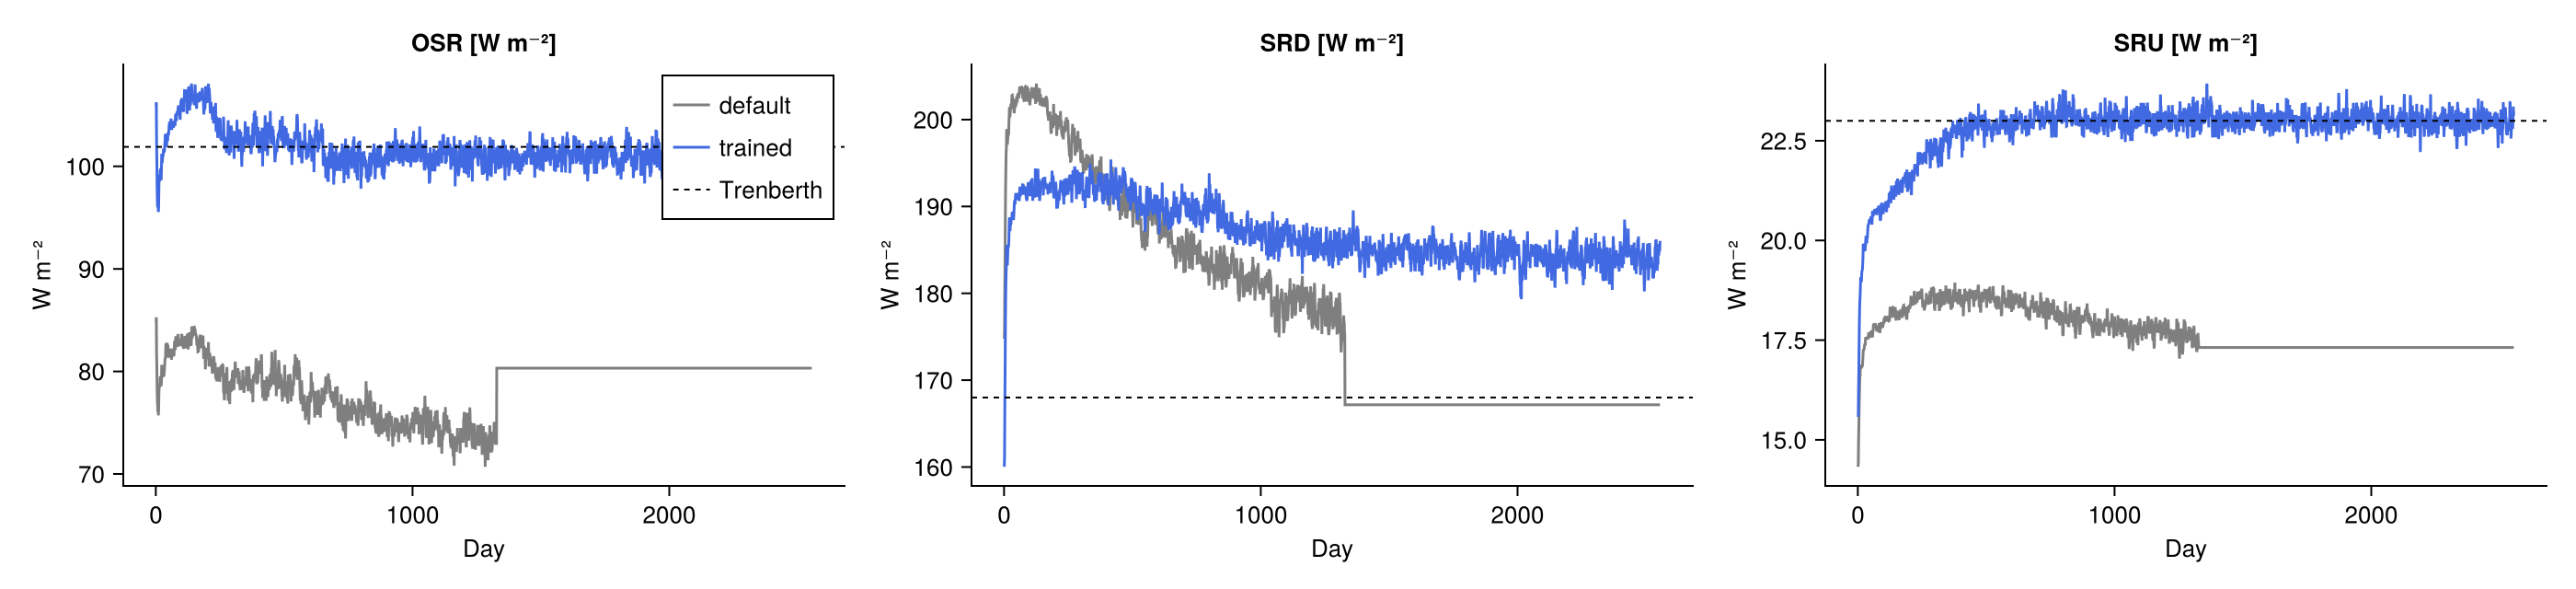

In [17]:
cfigs = plot_climate(validation; save_dir = save_dir, loss_config = sw_loss)
cfigs.fig_rad

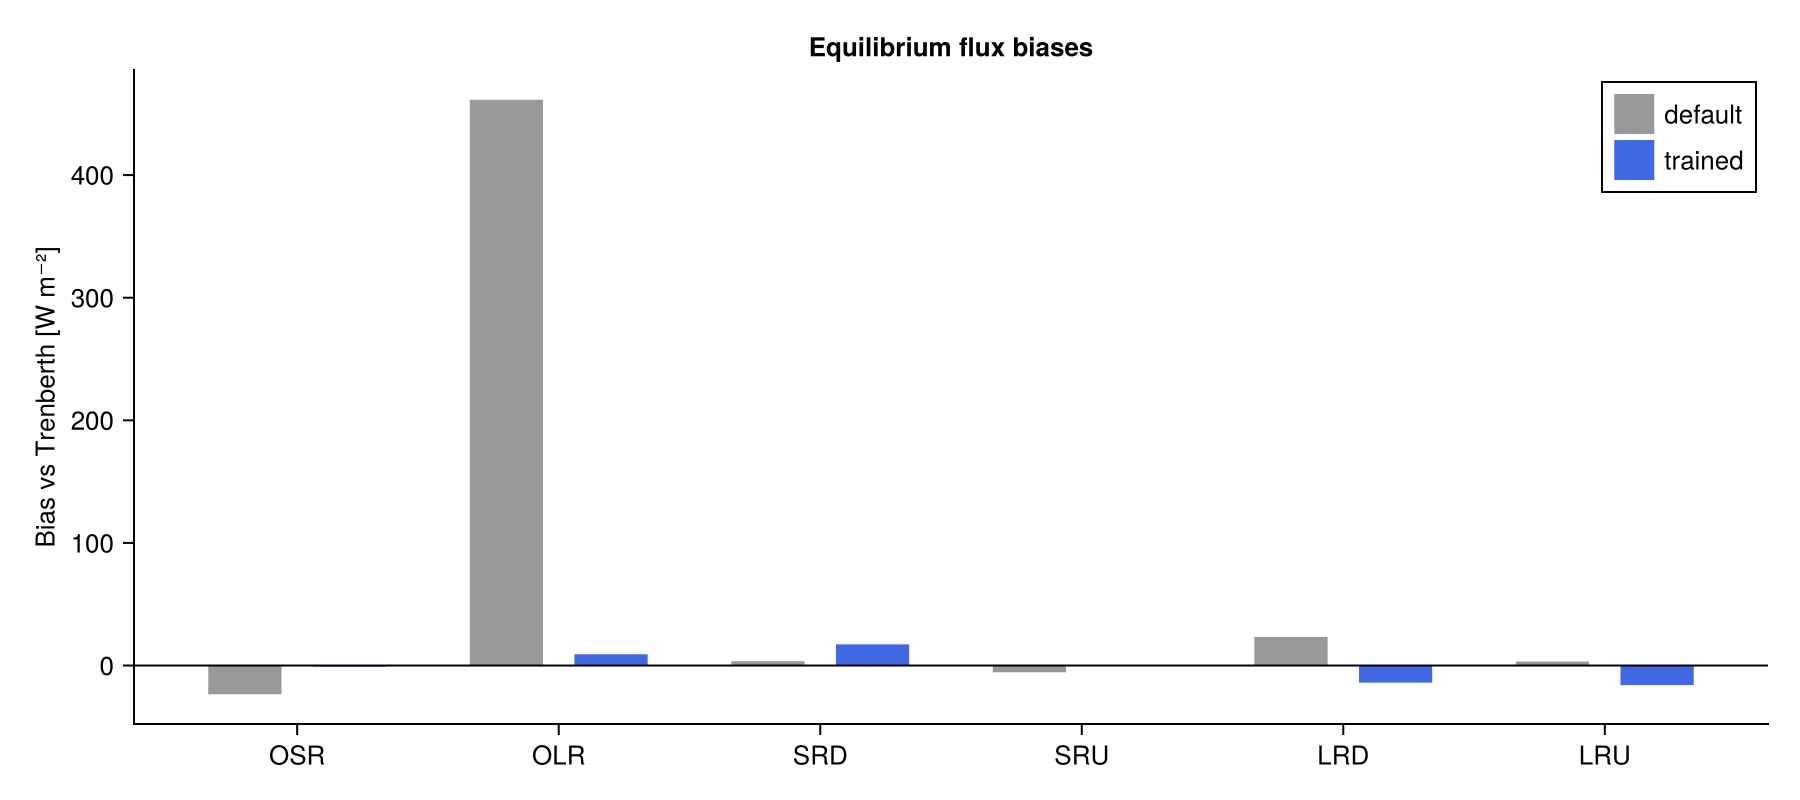

In [18]:
cfigs.fig_summary

## Summary

This notebook reproduces the thesis's multi-parameter shortwave calibration workflow:

1. **15 parameters** across cloud reflection (3), cloud cover (1), atmospheric
   absorption (4), land albedo (5), and ocean/ice albedo (2)
2. **OSR + SRU + SRD loss** with equal weights and Trenberth (2009) targets
3. **20-day spinup** + batches of 15 gradient samples every 30 simulated days,
   with the diurnal cycle enabled
4. **Full climate validation** to confirm improvements at 7-year timescales

Results are saved to `examples/output/thesis_15param_shortwave/`:
- `result.jld2` — full `TrainingResult` (resumable)
- `history.csv` — per-batch training history
- `final_weights.toml` — human-readable final parameter values
- `fig_*.pdf`, `climate_*.pdf` — figures matching the thesis